In [23]:
## importing packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import Longitude, Latitude, Angle
from astropy.io import fits
from astroquery.simbad import Simbad
from astroquery.hips2fits import hips2fits
# idk if I need all these packages but just putting here for now

In [9]:
## package installation

# uncomment the below line if the above cell throws an error
# %pip install numpy pandas matplotlib pillow scikit-learn astropy astroquery

# Data Extraction

In [42]:
## obtain the coordinates for the celestial bodies we are interested in

# list of query-able IDs
target_ids = ['HIP_27989', 'HIP_32349', 'HIP_91262'] # test - betelgeuse, sirius, vega
# TODO: assemble list of celestial bodies to survey

# right ascension (RA) and declination (dec) for target celestial bodies
target_coords = Simbad.query_objects(target_ids)['main_id', 'ra', 'dec']
print(target_coords)

 main_id          ra                dec        
                 deg                deg        
--------- ------------------ ------------------
* alf Ori  88.79293899077537  7.407063995272694
* alf CMa 101.28715533333335 -16.71611586111111
* alf Lyr   279.234734787025    38.783688956244


In [43]:
## obtain images for target celstial bodies from RA and dec
HIPS = 'CDS/P/DSS2/red'
WIDTH = 800
HEIGHT = 800
PROJECTION = 'TAN'
FORMAT = 'fits'

# a function to get the hips image from the right ascension (RA) and declination (Dec) and save to the working directory
# parameters:
#   ra: right ascension in degrees
#   dec: declination in degrees
#   id: name identifier for output FITS file
# returns: 
#   None
def get_hips_image(ra, dec, id):
   result = hips2fits.query(
      hips=HIPS,
      width=WIDTH,
      height=HEIGHT,
      projection=PROJECTION,
      ra=Longitude(ra * u.deg),
      dec=Latitude(dec * u.deg),
      fov=Angle(1 * u.deg),
      format=FORMAT
   )
   result.writeto(f'{id}.fits', overwrite=True)

# loop to obtain images for previously defined target celestial bodies
for i in range(len(target_coords)):
   get_hips_image(target_coords[i]['ra'], target_coords[i]['dec'], target_ids[i])

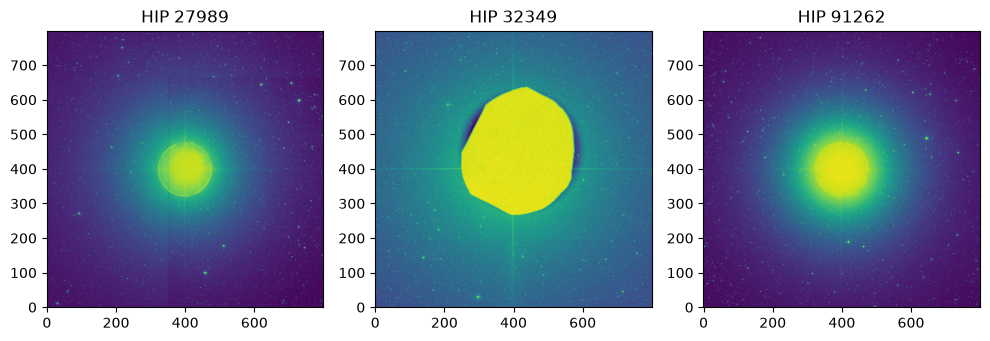

In [ ]:
## display image

# display images all at once for testing
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

# iterate through each celestial body for each subplot
for i in range(len(target_ids)):
   image_data = fits.getdata(f'{target_ids[i]}.fits', ext=0) # image data
   axes[i].imshow(image_data, cmap='viridis', origin='lower') # color mapping
   axes[i].set_title(' '.join(target_ids[i].split('_'))) # replace underscores with spaces

plt.tight_layout()
plt.show()

In [ ]:
## image processing:
# for each, determine what is in it (star, galaxy...) based on name data/img analysis (large bright dot vs many small bright dots)
# star -> determine color of star
# galaxy/star cluster -> determine number of stars